In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import ast
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch

from scipy.signal import butter, filtfilt, stft

In [ ]:
BASE = "/content/drive/MyDrive/Colab Notebooks"

X_PATH    = os.path.join(BASE, "X_ptbxl_500hz.npy")
META_PATH = os.path.join(BASE, "ptbxl_database.csv")
Y_PATH    = os.path.join(BASE, "Y_6labels.npy")
SPEC_PATH = os.path.join(BASE, "X_specs_12x41x38.npy")

print("X exists:", os.path.exists(X_PATH))
print("META exists:", os.path.exists(META_PATH))
print("Y exists:", os.path.exists(Y_PATH))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

X exists: True
META exists: True
Y exists: True
Device: cuda


In [ ]:
!cp "{X_PATH}" /content/X_ptbxl_500hz.npy

In [ ]:
#LoadrawECGandmetadata
X = np.load("/content/X_ptbxl_500hz.npy", mmap_mode="r")
print("X shape:", X.shape)   # expected (21799, 12, 5000)

meta = pd.read_csv(META_PATH)
meta["scp_codes"] = meta["scp_codes"].apply(ast.literal_eval)

print("Meta shape:", meta.shape)

X shape: (21799, 12, 5000)
Meta shape: (21799, 28)


In [ ]:
#Build labels if not already saved
classes = ["NORM", "IMI", "ASMI", "LVH", "NDT", "LAFB"]
class_to_idx = {c: i for i, c in enumerate(classes)}

Y = np.zeros((len(meta), len(classes)), dtype=np.float32)

for i, codes in enumerate(meta["scp_codes"]):
    for c in classes:
        if c in codes:
            Y[i, class_to_idx[c]] = 1.0

print("Y shape:", Y.shape)
print("Counts:", dict(zip(classes, Y.sum(axis=0).astype(int))))

assert X.shape[0] == Y.shape[0]

np.save(Y_PATH, Y)
print("Saved labels to:", Y_PATH)

Y shape: (21799, 6)
Counts: {'NORM': np.int64(9514), 'IMI': np.int64(2676), 'ASMI': np.int64(2357), 'LVH': np.int64(2132), 'NDT': np.int64(1825), 'LAFB': np.int64(1623)}
Saved labels to: /content/drive/MyDrive/Colab Notebooks/Y_6labels.npy


In [ ]:
#Bandpass + STFT functions
def bandpass_filter(x, fs=500, low=0.5, high=40.0, order=4):
    """
    x shape: (time, leads) = (5000, 12)
    """
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, x, axis=0)


def ecg_to_spectrogram_tensor(ecg_time_leads, fs=500, win_len=256, hop=128, nfft=512, fmax=40.0):
    """
    ecg_time_leads shape: (time, leads) = (5000, 12)
    returns: (12, F, T)
    """
    specs = []

    for lead in range(ecg_time_leads.shape[1]):   # 12 leads
        f, tt, Z = stft(
            ecg_time_leads[:, lead],
            fs=fs,
            nperseg=win_len,
            noverlap=win_len - hop,
            nfft=nfft,
            boundary=None,
            padded=False
        )

        mag = np.abs(Z)  # (freq, time)

        keep = f <= fmax
        mag = mag[keep, :]

        mag = np.log1p(mag)
        mag = (mag - mag.mean()) / (mag.std() + 1e-8)

        specs.append(mag.astype(np.float32))

    return np.stack(specs, axis=0)   # (12, F, T)

In [ ]:
#Test one sample first
sample_idx = 0

# X[sample_idx] is (12, 5000), so transpose to (5000, 12)
ecg = X[sample_idx].T

print("Raw sample shape:", ecg.shape)   # (5000, 12)

ecg_filt = bandpass_filter(ecg, fs=500)
ecg_filt = (ecg_filt - ecg_filt.mean(axis=0)) / (ecg_filt.std(axis=0) + 1e-8)

spec = ecg_to_spectrogram_tensor(ecg_filt, fs=500)

print("Spectrogram shape:", spec.shape)   # expected (12, 41, 38)

Raw sample shape: (5000, 12)
Spectrogram shape: (12, 41, 38)


In [ ]:
#Save all spectrograms
#Run this only once.
N = X.shape[0]
specs = np.zeros((N, 12, 41, 38), dtype=np.float32)

for i in tqdm(range(N), desc="Generating STFT spectrograms"):
    ecg = X[i].T   # (5000, 12)

    ecg_filt = bandpass_filter(ecg, fs=500)
    ecg_filt = (ecg_filt - ecg_filt.mean(axis=0)) / (ecg_filt.std(axis=0) + 1e-8)

    spec = ecg_to_spectrogram_tensor(ecg_filt, fs=500)   # (12,41,38)
    specs[i] = spec

print("All spectrograms shape:", specs.shape)

np.save(SPEC_PATH, specs)
print("Saved spectrograms to:", SPEC_PATH)

Generating STFT spectrograms: 100%|██████████| 21799/21799 [03:32<00:00, 102.42it/s]


All spectrograms shape: (21799, 12, 41, 38)
Saved spectrograms to: /content/drive/MyDrive/Colab Notebooks/X_specs_12x41x38.npy


In [ ]:
#Reload saved spectrograms
X_specs = np.load(SPEC_PATH, mmap_mode="r")
print("X_specs shape:", X_specs.shape)

X_specs shape: (21799, 12, 41, 38)


In [ ]:
#Train/val/test split

from sklearn.model_selection import GroupShuffleSplit

groups = meta["patient_id"].values
idx_all = np.arange(len(meta))

gss = GroupShuffleSplit(test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss.split(idx_all, Y, groups))

gss2 = GroupShuffleSplit(test_size=0.25, random_state=42)
train_rel, val_rel = next(gss2.split(train_val_idx, Y[train_val_idx], groups[train_val_idx]))

train_idx = train_val_idx[train_rel]
val_idx   = train_val_idx[val_rel]

print("train/val/test:", len(train_idx), len(val_idx), len(test_idx))

train/val/test: 13121 4302 4376


In [ ]:
#Dataset class
from torch.utils.data import Dataset, DataLoader

class FusionECGDataset(Dataset):
    def __init__(self, X_raw, X_spec, Y, indices):
        self.X_raw = X_raw
        self.X_spec = X_spec
        self.Y = Y
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        raw_ecg = torch.tensor(self.X_raw[i], dtype=torch.float32)   # (12,5000)
        spec    = torch.tensor(self.X_spec[i], dtype=torch.float32)  # (12,41,38)
        label   = torch.tensor(self.Y[i], dtype=torch.float32)       # (6,)

        return raw_ecg, spec, label

In [ ]:
#Dataloaders
train_ds = FusionECGDataset(X, X_specs, Y, train_idx)
val_ds   = FusionECGDataset(X, X_specs, Y, val_idx)
test_ds  = FusionECGDataset(X, X_specs, Y, test_idx)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
#Check one batch
raw_batch, spec_batch, label_batch = next(iter(train_loader))

print("Raw batch shape:", raw_batch.shape)     # (B, 12, 5000)
print("Spec batch shape:", spec_batch.shape)   # (B, 12, 41, 38)
print("Label batch shape:", label_batch.shape) # (B, 6)

Raw batch shape: torch.Size([32, 12, 5000])
Spec batch shape: torch.Size([32, 12, 41, 38])
Label batch shape: torch.Size([32, 6])


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


3) Dataset class

This gives one sample as:

raw ECG
spectrogram
label

In [ ]:
class FusionECGDataset(Dataset):
    def __init__(self, X_raw, X_spec, Y, indices):
        self.X_raw = X_raw
        self.X_spec = X_spec
        self.Y = Y
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]

        raw_ecg = torch.tensor(self.X_raw[i], dtype=torch.float32)   # (12, 5000)
        spec    = torch.tensor(self.X_spec[i], dtype=torch.float32)  # (12, 41, 38)
        label   = torch.tensor(self.Y[i], dtype=torch.float32)       # (6,)

        return raw_ecg, spec, label

In [ ]:
batch_size = 32

train_ds = FusionECGDataset(X, X_specs, Y, train_idx)
val_ds   = FusionECGDataset(X, X_specs, Y, val_idx)
test_ds  = FusionECGDataset(X, X_specs, Y, test_idx)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
#Check one batch
raw_batch, spec_batch, label_batch = next(iter(train_loader))

print("Raw batch shape   :", raw_batch.shape)     # expected (B, 12, 5000)
print("Spec batch shape  :", spec_batch.shape)    # expected (B, 12, 41, 38)
print("Label batch shape :", label_batch.shape)   # expected (B, 6)

Raw batch shape   : torch.Size([32, 12, 5000])
Spec batch shape  : torch.Size([32, 12, 41, 38])
Label batch shape : torch.Size([32, 6])


In [ ]:
#Raw ECG branch (1D CNN)
class RawECGBranch(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(12, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.fc = nn.Linear(128, out_dim)

    def forward(self, x):
        # x: (B, 12, 5000)
        x = self.features(x)      # (B, 128, 1)
        x = x.squeeze(-1)         # (B, 128)
        x = self.fc(x)            # (B, out_dim)
        return x

In [ ]:
#Spectrogram branch (2D CNN)
class SpectrogramBranch(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(12, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.fc = nn.Linear(128, out_dim)

    def forward(self, x):
        # x: (B, 12, 41, 38)
        x = self.features(x)       # (B, 128, 1, 1)
        x = x.view(x.size(0), -1)  # (B, 128)
        x = self.fc(x)             # (B, out_dim)
        return x

In [ ]:
#Fusion model
class FusionModel(nn.Module):
    def __init__(self, num_classes=6, raw_dim=128, spec_dim=128):
        super().__init__()

        self.raw_branch = RawECGBranch(out_dim=raw_dim)
        self.spec_branch = SpectrogramBranch(out_dim=spec_dim)

        self.classifier = nn.Sequential(
            nn.Linear(raw_dim + spec_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, raw_x, spec_x):
        raw_feat = self.raw_branch(raw_x)     # (B, raw_dim)
        spec_feat = self.spec_branch(spec_x)  # (B, spec_dim)

        fused = torch.cat([raw_feat, spec_feat], dim=1)
        logits = self.classifier(fused)       # (B, 6)

        return logits

In [ ]:
#Create model
model = FusionModel(num_classes=6).to(device)
print(model)

FusionModel(
  (raw_branch): RawECGBranch(
    (features): Sequential(
      (0): Conv1d(12, 32, kernel_size=(7,), stride=(1,), padding=(3,))
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): AdaptiveAvgPool1d(output_size=1)
    )
    (fc): Linear(in_features=128, out_features=128, bias=True)
  )
  (spec_branch): SpectrogramBranch(
    (features): Sequential(
      (0): Conv2d(12, 32, kernel

In [ ]:
#Test one forward pass
raw_batch, spec_batch, label_batch = next(iter(train_loader))

raw_batch = raw_batch.to(device)
spec_batch = spec_batch.to(device)

with torch.no_grad():
    out = model(raw_batch, spec_batch)

print("Model output shape:", out.shape)   # expected (B, 6)

Model output shape: torch.Size([32, 6])


In [ ]:
#Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
#Training function
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for raw_x, spec_x, y in loader:
        raw_x = raw_x.to(device)
        spec_x = spec_x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(raw_x, spec_x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * raw_x.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

In [ ]:
#Validation function
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for raw_x, spec_x, y in loader:
            raw_x = raw_x.to(device)
            spec_x = spec_x.to(device)
            y = y.to(device)

            logits = model(raw_x, spec_x)
            loss = criterion(logits, y)

            probs = torch.sigmoid(logits)

            running_loss += loss.item() * raw_x.size(0)
            all_probs.append(probs.cpu())
            all_labels.append(y.cpu())

    epoch_loss = running_loss / len(loader.dataset)
    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return epoch_loss, all_probs, all_labels

In [ ]:
classes = ["NORM", "IMI", "ASMI", "LVH", "NDT", "LAFB"]

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {}

    per_label = {}
    for i, cls in enumerate(classes):
        acc = accuracy_score(y_true[:, i], y_pred[:, i])
        prec = precision_score(y_true[:, i], y_pred[:, i], zero_division=0)
        rec = recall_score(y_true[:, i], y_pred[:, i], zero_division=0)
        f1 = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)

        try:
            auc = roc_auc_score(y_true[:, i], y_prob[:, i])
        except:
            auc = np.nan

        per_label[cls] = {
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "auroc": auc
        }

    macro_accuracy = np.mean([per_label[c]["accuracy"] for c in classes])
    macro_precision = np.mean([per_label[c]["precision"] for c in classes])
    macro_recall = np.mean([per_label[c]["recall"] for c in classes])
    macro_f1 = np.mean([per_label[c]["f1"] for c in classes])

    valid_aurocs = [per_label[c]["auroc"] for c in classes if not np.isnan(per_label[c]["auroc"])]
    macro_auroc = np.mean(valid_aurocs) if len(valid_aurocs) > 0 else np.nan

    metrics["per_label"] = per_label
    metrics["macro_accuracy"] = macro_accuracy
    metrics["macro_precision"] = macro_precision
    metrics["macro_recall"] = macro_recall
    metrics["macro_f1"] = macro_f1
    metrics["macro_auroc"] = macro_auroc

    return metrics

In [ ]:
#Pretty print metrics
def print_metrics(metrics):
    print("\nPer-label metrics:")
    for cls, vals in metrics["per_label"].items():
        print(
            f"{cls:5s} | "
            f"Acc: {vals['accuracy']:.4f} | "
            f"Prec: {vals['precision']:.4f} | "
            f"Rec: {vals['recall']:.4f} | "
            f"F1: {vals['f1']:.4f} | "
            f"AUROC: {vals['auroc']:.4f}"
        )

    print("\nMacro metrics:")
    print(f"Macro Accuracy : {metrics['macro_accuracy']:.4f}")
    print(f"Macro Precision: {metrics['macro_precision']:.4f}")
    print(f"Macro Recall   : {metrics['macro_recall']:.4f}")
    print(f"Macro F1       : {metrics['macro_f1']:.4f}")
    print(f"Macro AUROC    : {metrics['macro_auroc']:.4f}")

In [ ]:
#Training loop
num_epochs = 10
best_val_loss = float("inf")
best_model_path = "/content/best_fusion_model.pth"

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_probs, val_labels = evaluate(model, val_loader, criterion, device)

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss  : {val_loss:.4f}")

    val_metrics = compute_metrics(val_labels, val_probs, threshold=0.5)
    print_metrics(val_metrics)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved.")


Epoch [1/10]
Train Loss: 0.3134
Val Loss  : 0.2693

Per-label metrics:
NORM  | Acc: 0.8236 | Prec: 0.7503 | Rec: 0.8858 | F1: 0.8125 | AUROC: 0.9130
IMI   | Acc: 0.8675 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000 | AUROC: 0.7351
ASMI  | Acc: 0.8924 | Prec: 0.7143 | Rec: 0.0523 | F1: 0.0975 | AUROC: 0.8499
LVH   | Acc: 0.9117 | Prec: 0.5151 | Rec: 0.4385 | F1: 0.4737 | AUROC: 0.9067
NDT   | Acc: 0.9247 | Prec: 0.4000 | Rec: 0.0124 | F1: 0.0241 | AUROC: 0.8042
LAFB  | Acc: 0.9340 | Prec: 0.7526 | Rec: 0.2192 | F1: 0.3395 | AUROC: 0.9090

Macro metrics:
Macro Accuracy : 0.8923
Macro Precision: 0.5220
Macro Recall   : 0.2680
Macro F1       : 0.2912
Macro AUROC    : 0.8530
Best model saved.

Epoch [2/10]
Train Loss: 0.2620
Val Loss  : 0.2611

Per-label metrics:
NORM  | Acc: 0.8187 | Prec: 0.7323 | Rec: 0.9138 | F1: 0.8130 | AUROC: 0.9184
IMI   | Acc: 0.8675 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000 | AUROC: 0.7726
ASMI  | Acc: 0.8966 | Prec: 0.8667 | Rec: 0.0816 | F1: 0.1491 | AUROC: 0.9110


In [ ]:
#Load best model
model.load_state_dict(torch.load(best_model_path))
model.eval()
print("Best model loaded.")

Best model loaded.


In [ ]:
#Test evaluation
test_loss, test_probs, test_labels = evaluate(model, test_loader, criterion, device)

print("Test Loss:", round(test_loss, 4))

test_metrics = compute_metrics(test_labels, test_probs, threshold=0.5)
print_metrics(test_metrics)

Test Loss: 0.1902

Per-label metrics:
NORM  | Acc: 0.8654 | Prec: 0.8033 | Rec: 0.9234 | F1: 0.8592 | AUROC: 0.9454
IMI   | Acc: 0.9022 | Prec: 0.7797 | Rec: 0.2619 | F1: 0.3920 | AUROC: 0.9181
ASMI  | Acc: 0.9440 | Prec: 0.8000 | Rec: 0.6009 | F1: 0.6863 | AUROC: 0.9554
LVH   | Acc: 0.9349 | Prec: 0.7864 | Rec: 0.4020 | F1: 0.5320 | AUROC: 0.9370
NDT   | Acc: 0.9205 | Prec: 0.6833 | Rec: 0.1108 | F1: 0.1907 | AUROC: 0.8820
LAFB  | Acc: 0.9623 | Prec: 0.7786 | Rec: 0.6677 | F1: 0.7189 | AUROC: 0.9760

Macro metrics:
Macro Accuracy : 0.9215
Macro Precision: 0.7719
Macro Recall   : 0.4945
Macro F1       : 0.5632
Macro AUROC    : 0.9357


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_combined_roc(y_true, y_prob, classes):
    plt.figure(figsize=(8, 6))

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.3f})")

    # diagonal line
    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves (All Classes)")
    plt.legend(loc="lower right")
    plt.grid(True)

    plt.show()

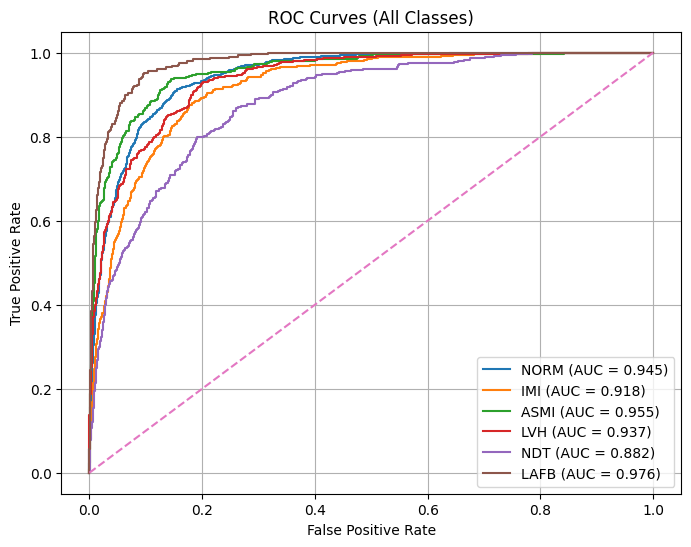

In [ ]:
plot_combined_roc(test_labels, test_probs, classes)

In [ ]:
test_metrics = compute_metrics(test_labels, test_probs, threshold=0.5)
print_metrics(test_metrics)


Per-label metrics:
NORM  | Acc: 0.8654 | Prec: 0.8033 | Rec: 0.9234 | F1: 0.8592 | AUROC: 0.9454
IMI   | Acc: 0.9022 | Prec: 0.7797 | Rec: 0.2619 | F1: 0.3920 | AUROC: 0.9181
ASMI  | Acc: 0.9440 | Prec: 0.8000 | Rec: 0.6009 | F1: 0.6863 | AUROC: 0.9554
LVH   | Acc: 0.9349 | Prec: 0.7864 | Rec: 0.4020 | F1: 0.5320 | AUROC: 0.9370
NDT   | Acc: 0.9205 | Prec: 0.6833 | Rec: 0.1108 | F1: 0.1907 | AUROC: 0.8820
LAFB  | Acc: 0.9623 | Prec: 0.7786 | Rec: 0.6677 | F1: 0.7189 | AUROC: 0.9760

Macro metrics:
Macro Accuracy : 0.9215
Macro Precision: 0.7719
Macro Recall   : 0.4945
Macro F1       : 0.5632
Macro AUROC    : 0.9357


In [ ]:
import json

with open("/content/fusion_results.json", "w") as f:
    json.dump(test_metrics, f, indent=4)

print("Saved fusion results")

Saved fusion results


In [ ]:
results = pd.DataFrame([
    ["Logistic Regression", 0.624],
    ["Random Forest", 0.660],
    ["k-NN", 0.461],
    ["SVM", 0.580],
    ["CNN", 0.696],
    ["LSTM", 0.585],
    ["CNN + BiLSTM", 0.657],
    ["Fusion (Raw + Spec)", test_metrics["macro_f1"]],
], columns=["Model", "Macro F1"])

print(results)

                 Model  Macro F1
0  Logistic Regression  0.624000
1        Random Forest  0.660000
2                 k-NN  0.461000
3                  SVM  0.580000
4                  CNN  0.696000
5                 LSTM  0.585000
6         CNN + BiLSTM  0.657000
7  Fusion (Raw + Spec)  0.563194
